In [2]:
from __future__ import annotations

from typing import Callable, Literal
import torch
import torch.nn.functional as F
import numpy as np
import scipy as sp
import matplotlib.pyplot as plt
from matplotlib.ticker import MaxNLocator
%matplotlib inline
import math
from pathlib import Path

In [3]:
%config InlineBackend.figure_format = 'retina'
plt.rcParams['font.size'] = 12
plt.rcParams['savefig.format'] = 'pdf'

In [4]:
def ensure_file(path: Path | str, strict: bool = True) -> Path:
    path = Path(path)

    if not path.exists() or not path.is_file():
        if strict:
            raise FileNotFoundError(f"File on path: {path} not found")
        path.parent.mkdir(parents=True, exist_ok=True)
        path.touch()

    return path


def ensure_dir(path: Path | str, strict: bool = False) -> Path:
    path = Path(path)

    if not path.exists() or not path.is_dir():
        if strict:
            raise FileNotFoundError(f"Dir on path: {path} not found")
        path.mkdir(parents=True, exist_ok=True)

    return path

In [5]:
root = Path('../')
config = root / 'config'
runs = root / 'runs'
res = root / 'res'

In [6]:
def get_run_data(path: Path):
    outlog_path = path / 'logs' / 'stdout.log'
    
    # iter 19520: loss 1.5558, time 3139.75ms, mfu 2.80%
    
    iter: list[int] = []
    loss: list[float] = []
    time: list[float] = []
    mfu: list[float] = []
    
    ensure_file(outlog_path)
    
    with outlog_path.open("r", encoding="utf-8") as f:
        for row in f:
            d = row.split()
            if len(d) < 1 or d[0] != 'iter':
                continue
            
            iter.append(int(d[1][:-1]))
            loss.append(float(d[3][:-1]))
            time.append(float(d[5][:-3]))
            mfu.append(float(d[7][:-1]))
            
    return (
        np.array(iter, dtype=int),
        np.array(loss, dtype=float),
        np.array(time, dtype=float),
        np.array(mfu, dtype=float),
    )

[PosixPath('../runs/3834480_0_ftl_F_1_2026-04-06_05-08-58'), PosixPath('../runs/3834480_1_ftl_F_1_2026-04-06_05-08-58'), PosixPath('../runs/3834480_2_ftl_F_1_2026-04-06_05-08-58'), PosixPath('../runs/3834480_3_ftl_F_1_2026-04-06_05-08-58'), PosixPath('../runs/3834480_4_ftl_F_1_2026-04-06_13-09-47'), PosixPath('../runs/3834485_0_ftl_F_2_2026-04-06_13-11-17'), PosixPath('../runs/3834485_1_ftl_F_2_2026-04-06_13-15-18'), PosixPath('../runs/3834485_2_ftl_F_2_2026-04-06_13-31-51'), PosixPath('../runs/3834485_3_ftl_F_2_2026-04-06_21-11-58'), PosixPath('../runs/3834485_4_ftl_F_2_2026-04-06_21-13-58'), PosixPath('../runs/3834486_0_ftl_F_3_2026-04-06_21-15-58'), PosixPath('../runs/3834486_1_ftl_F_3_2026-04-06_21-32-02'), PosixPath('../runs/3834486_2_ftl_F_3_2026-04-07_05-19-39'), PosixPath('../runs/3834486_3_ftl_F_3_2026-04-07_05-34-03'), PosixPath('../runs/3834486_4_ftl_F_3_2026-04-07_06-31-09'), PosixPath('../runs/3840346_0_ftl_F_4_2026-04-07_06-42-02'), PosixPath('../runs/3840346_1_ftl_F_4_20

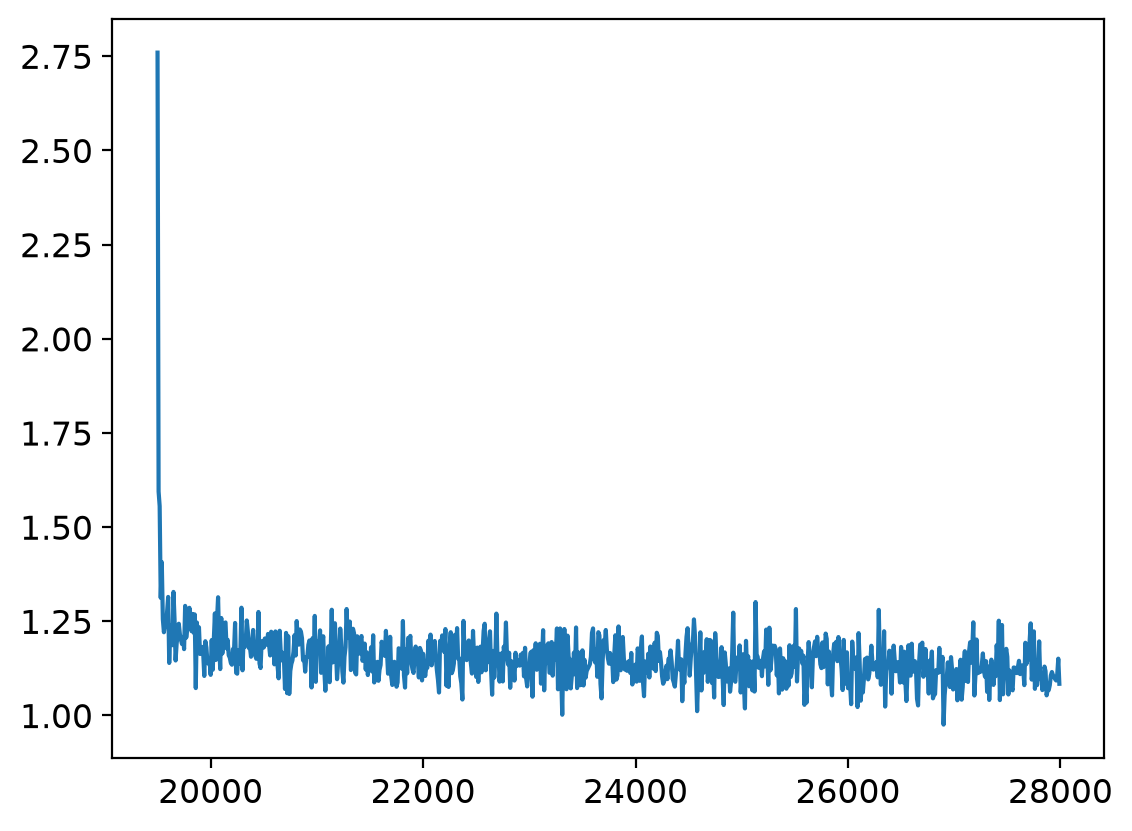

In [7]:
cruns = sorted(list([p for p in runs.iterdir()]))

print(cruns)
print(len(cruns) // 5)

run1 = cruns[0]
print(run1)

data1 = get_run_data(run1)

plt.plot(data1[0], data1[1], label='loss')

plt.show()

In [8]:
def get_run_data_mean(name: str):
    need_runs = [p for p in runs.iterdir() if name in p.name]
    data = [get_run_data(p) for p in need_runs]
    
    if not data:
        raise ValueError(f"No runs found for name={name!r}")

    max_len = max(len(run_data[0]) for run_data in data)

    longest = max(data, key=lambda run_data: len(run_data[0]))
    iters = longest[0].copy()

    means = []

    for metric_idx in range(1, 4):
        cur_mean = np.zeros((max_len,), dtype=float)

        for i in range(max_len):
            vals = [
                run_data[metric_idx][i]
                for run_data in data
                if i < len(run_data[metric_idx])
            ]
            cur_mean[i] = np.mean(vals)

        means.append(cur_mean)

    return (
        iters,
        means[0],
        means[1],
        means[2],
    )
    

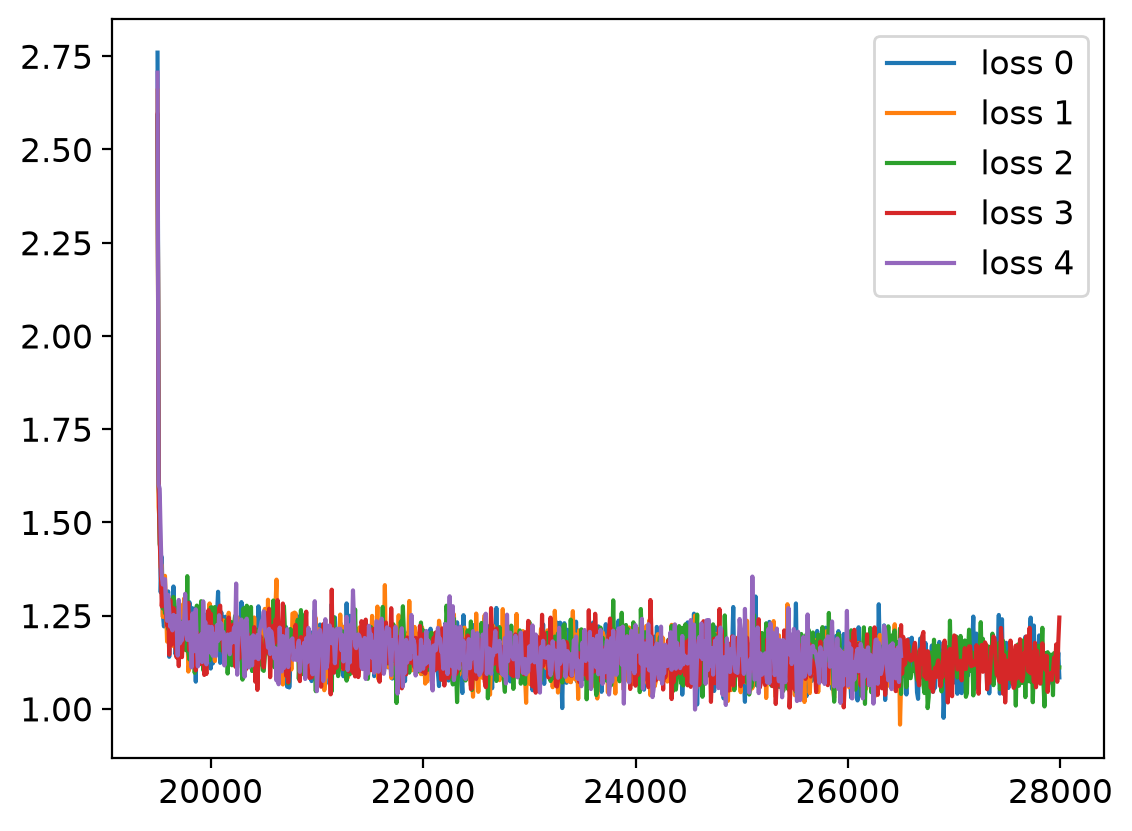

In [9]:
for i in range(5):
    path = cruns[i]
    
    data = get_run_data(path)
    
    plt.plot(data[0], data[1], label=f'loss {i}')
    
plt.legend()
plt.show()
    

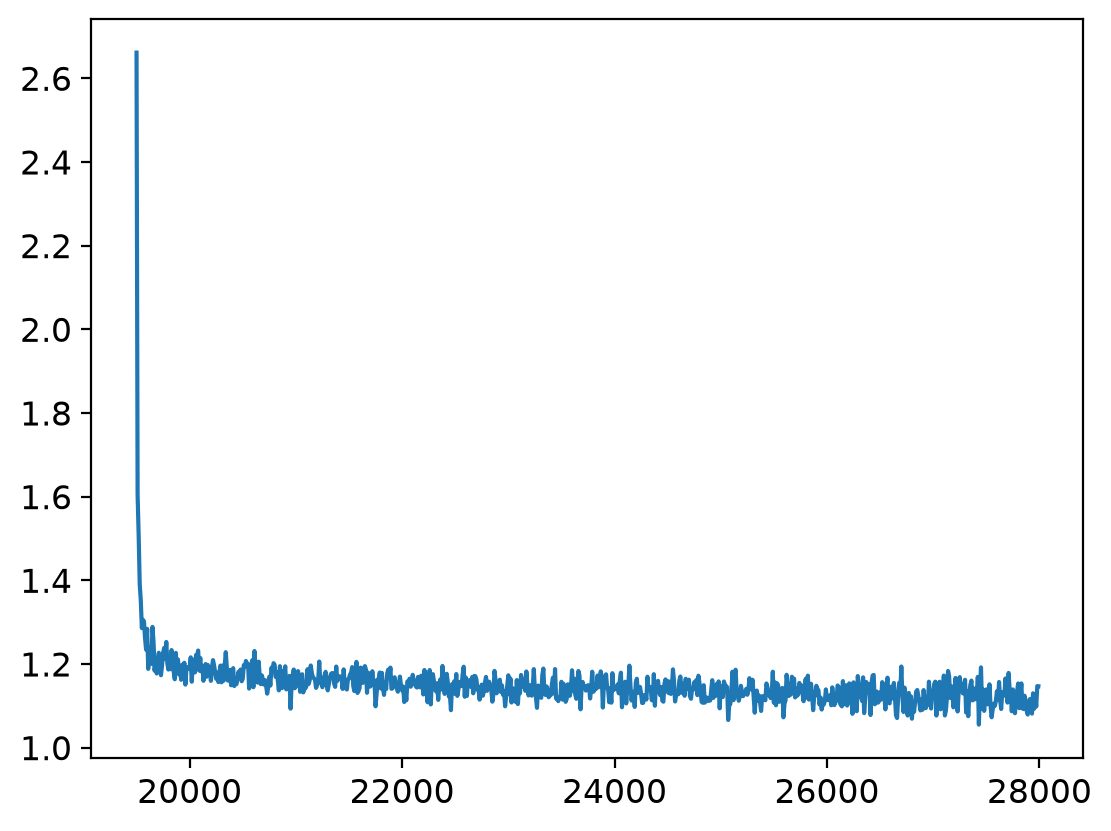

In [10]:
run_data_F_1 = get_run_data_mean('F_1_')

plt.plot(run_data_F_1[0], run_data_F_1[1], label='loss')
plt.show()

In [80]:
def moving_average(x: np.ndarray, window: int = 50) -> np.ndarray:
    x = np.asarray(x, dtype=float)

    if window <= 1 or len(x) == 0:
        return x.copy()

    n = len(x)

    left = window // 2
    right = window - 1 - left

    res = np.empty(n, dtype=float)

    for i in range(n):
        l = max(0, i - left)
        r = min(n, i + right + 1)

        res[i] = np.nanmean(x[l:r])

    return res


def aggregate_run_data(name: str):
    need_runs = [p for p in cruns if name in p.name]
    data = [get_run_data(p) for p in need_runs]

    if not data:
        raise ValueError(f"No runs found for name={name!r}")

    max_len = max(len(d[0]) for d in data)
    longest = max(data, key=lambda d: len(d[0]))

    iters = longest[0].copy()

    means = []
    stds = []
    sems = []
    counts = np.zeros(max_len, dtype=int)

    for metric_idx in range(1, 4):  # loss, time, mfu
        mean = np.full(max_len, np.nan, dtype=float)
        std = np.full(max_len, np.nan, dtype=float)
        sem = np.full(max_len, np.nan, dtype=float)

        for i in range(max_len):
            vals = np.array([
                d[metric_idx][i]
                for d in data
                if i < len(d[metric_idx])
            ], dtype=float)

            if len(vals) == 0:
                continue

            mean[i] = vals.mean()
            std[i] = vals.std(ddof=1) if len(vals) > 1 else 0.0
            sem[i] = std[i] / np.sqrt(len(vals))

            if metric_idx == 1:
                counts[i] = len(vals)

        means.append(mean)
        stds.append(std)
        sems.append(sem)

    return {
        "runs": need_runs,
        "data": data,
        "iters": iters,
        "loss_mean": means[0],
        "loss_std": stds[0],
        "loss_sem": sems[0],
        "time_mean": means[1],
        "time_std": stds[1],
        "time_sem": sems[1],
        "mfu_mean": means[2],
        "mfu_std": stds[2],
        "mfu_sem": sems[2],
        "counts": counts,
    }

In [65]:
def plot_loss_runs(
    name: str,
    window: int = 50,
    band: str = "sem",      # "std" или "sem"
    min_count: int = 1,
    ylim_quantile: float | None = 0.99,
):
    agg = aggregate_run_data(name)

    iters = agg["iters"]
    loss_mean = agg["loss_mean"]
    loss_std = agg["loss_std"]
    loss_sem = agg["loss_sem"]
    counts = agg["counts"]

    mask = counts >= min_count

    x = iters[mask]
    y = loss_mean[mask]

    err = loss_sem if band == "sem" else loss_std
    err = err[mask]

    y_smooth = moving_average(y, window)
    err_smooth = moving_average(err, window)

    fig, ax = plt.subplots(figsize=(12, 6), dpi=130)

    # отдельные запуски
    for i, d in enumerate(agg["data"]):
        cur_iters, cur_loss, _cur_time, _cur_mfu = d
        ax.plot(
            cur_iters,
            cur_loss,
            linewidth=0.8,
            alpha=0.25,
            label=f"run {i}" if i < 5 else None,
        )

    # среднее
    ax.plot(
        x,
        y_smooth,
        linewidth=2.5,
        label=f"mean, rolling={window}",
    )

    # коридор
    ax.fill_between(
        x,
        y_smooth - err_smooth,
        y_smooth + err_smooth,
        alpha=0.3,
        label=f"mean ± {band}",
    )

    ax.set_title(f"{name}: loss over iterations")
    ax.set_xlabel("iteration")
    ax.set_ylabel("loss")
    ax.grid(True, alpha=0.3)
    ax.legend()

    if ylim_quantile is not None:
        vals = np.concatenate([d[1] for d in agg["data"]])
        lo = np.nanquantile(vals, 1 - ylim_quantile)
        hi = np.nanquantile(vals, ylim_quantile)
        pad = 0.05 * (hi - lo)
        ax.set_ylim(lo - pad, hi + pad)
    # ax.set_ylim(1.0, 2)

    plt.show()

    # отдельный график количества активных запусков
    fig, ax = plt.subplots(figsize=(12, 1), dpi=130)
    ax.plot(iters, counts, linewidth=2)
    ax.yaxis.set_major_locator(MaxNLocator(integer=True))
    ax.set_title(f"{name}: number of runs used in mean")
    ax.set_xlabel("iteration")
    ax.set_ylabel("n")
    ax.grid(True, alpha=0.3)
    plt.show()

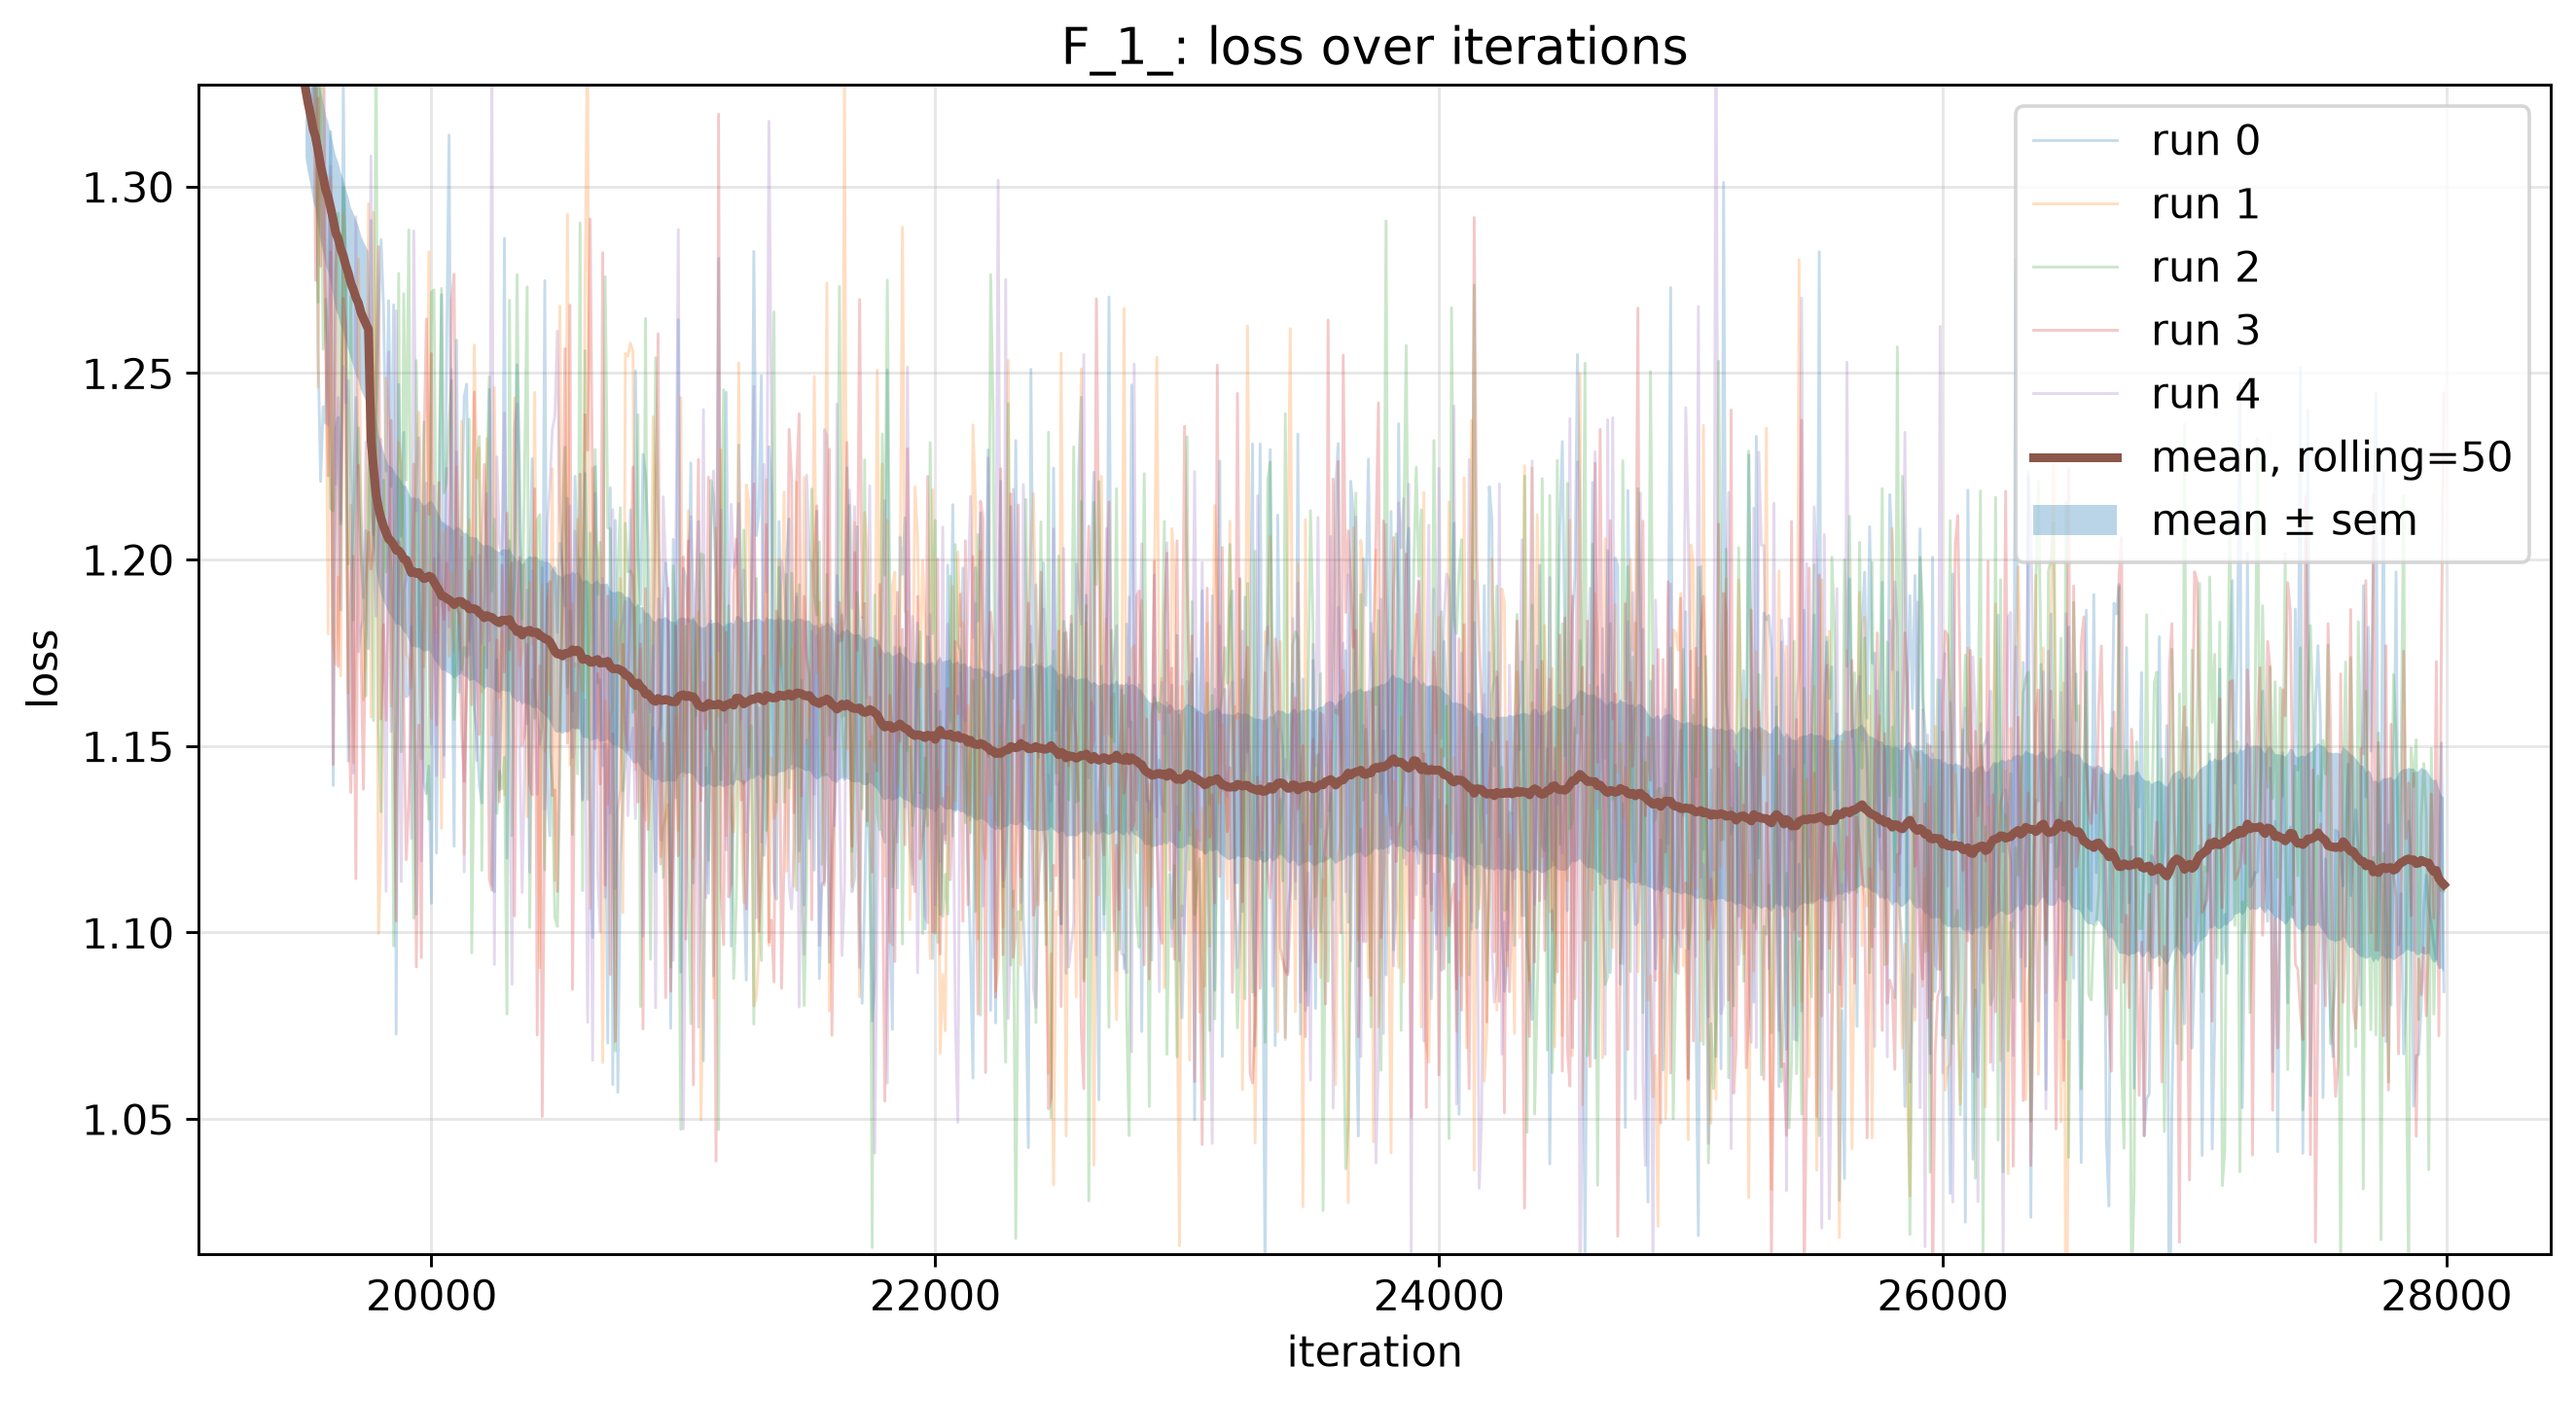

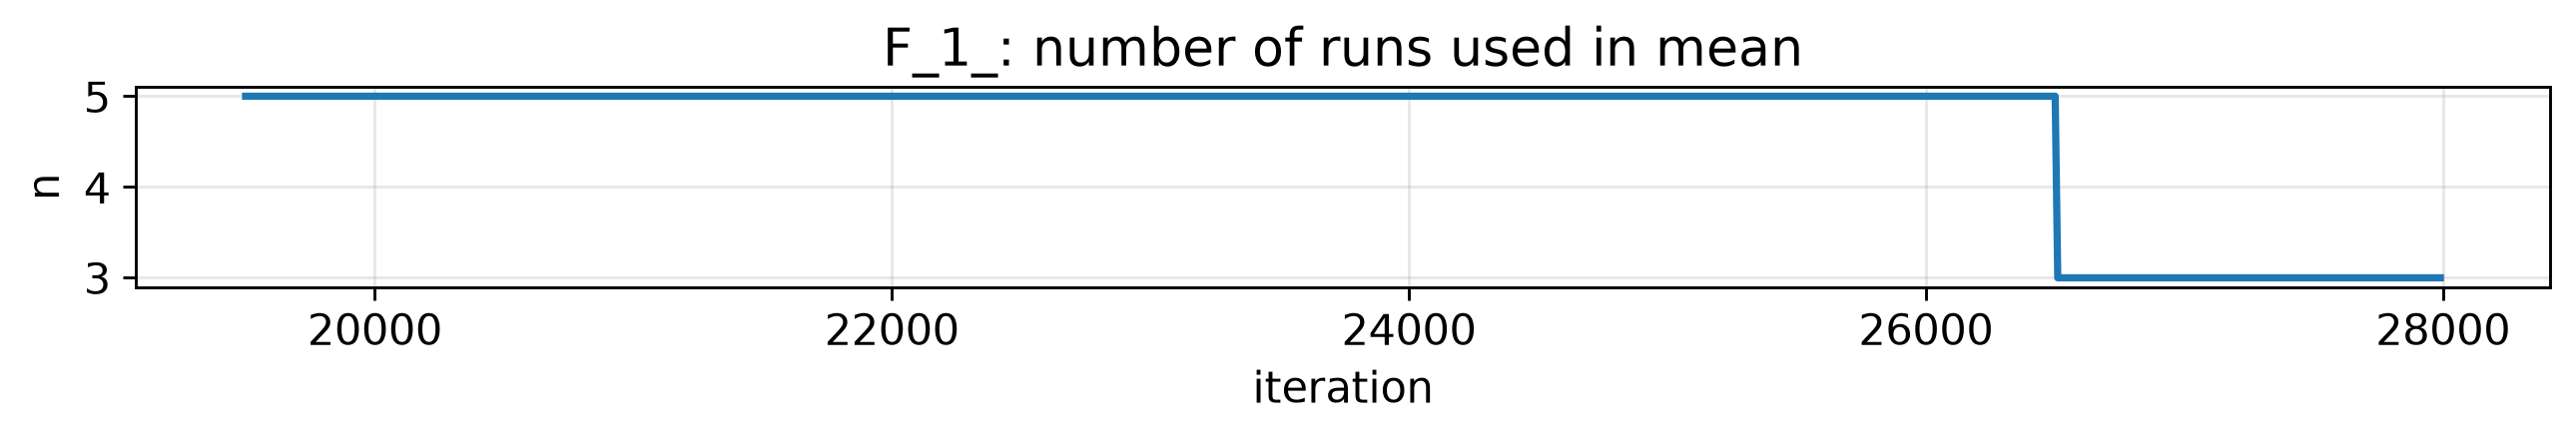

In [81]:
plot_loss_runs("F_1_", window=50, band="sem", min_count=1)

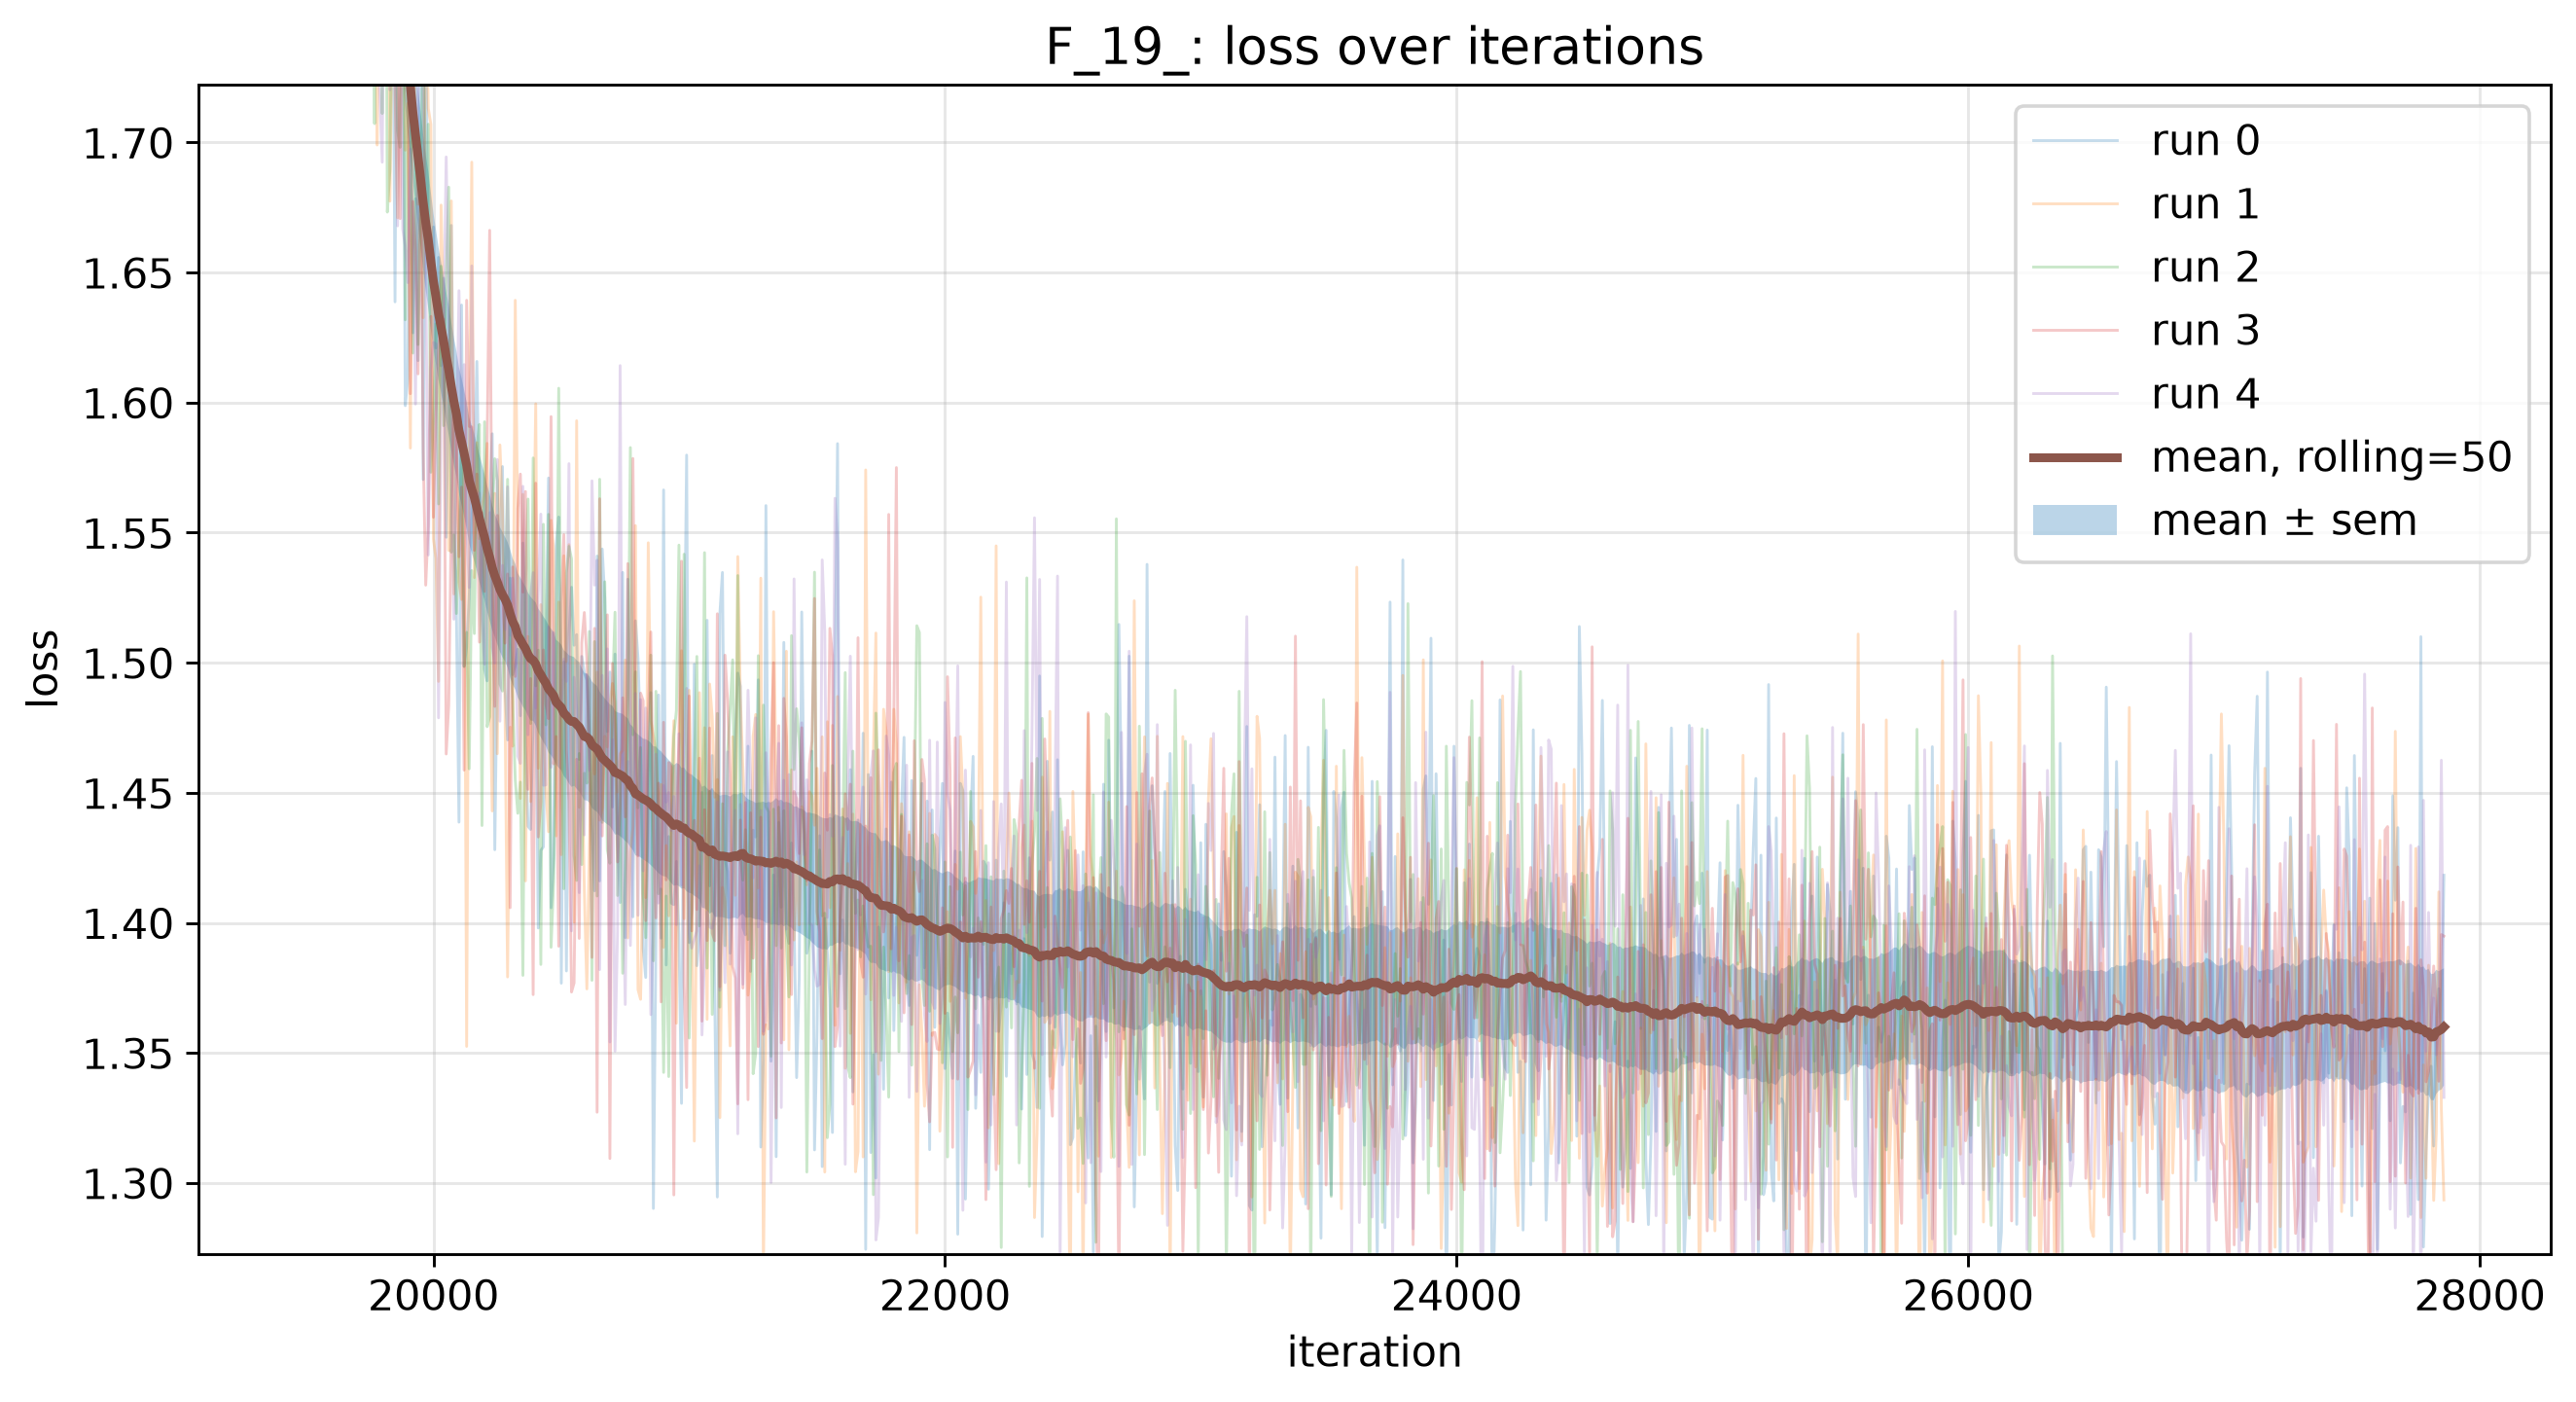

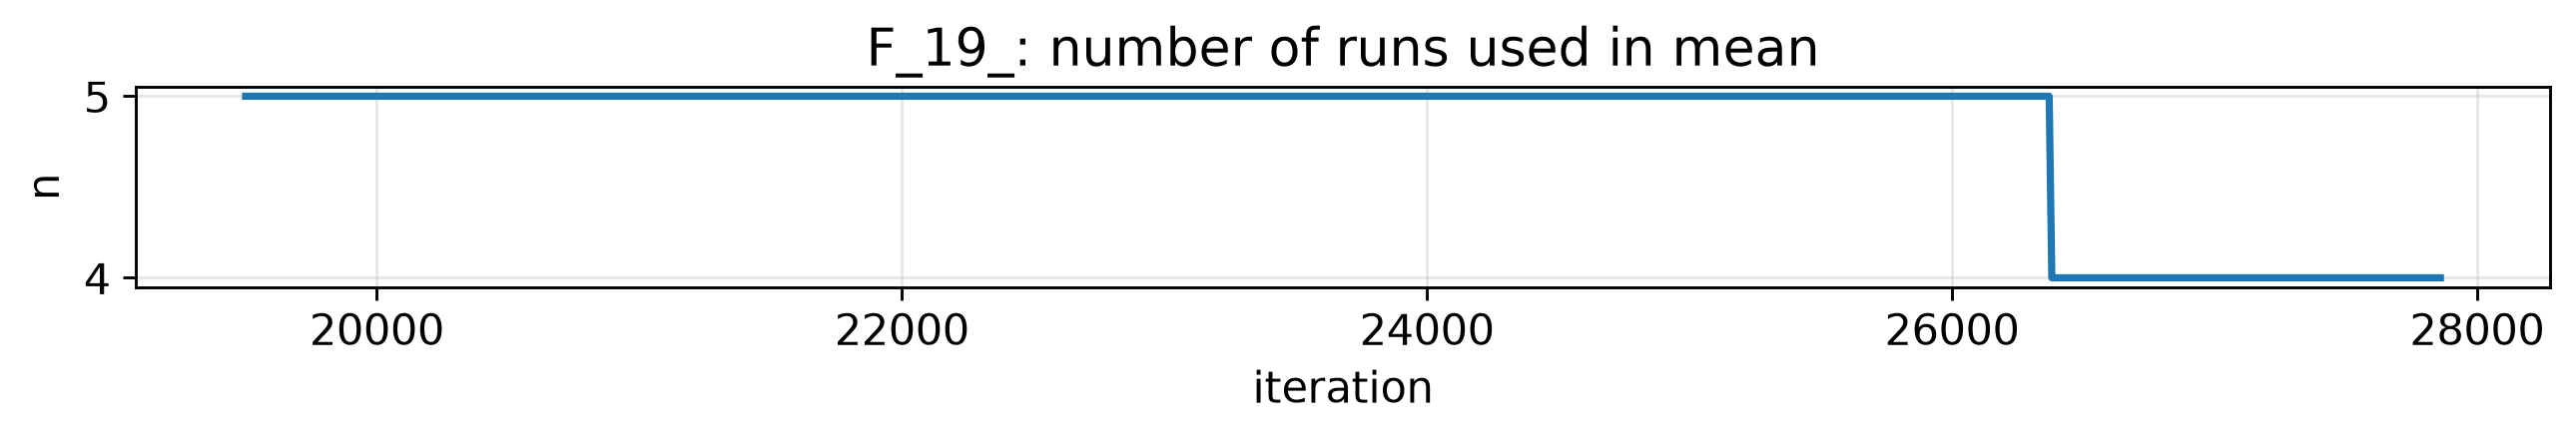

In [82]:
plot_loss_runs("F_19_", window=50, band="sem", min_count=1, ylim_quantile=0.95)

In [18]:
def get_name(id: int):
    return f'F_{id}'

In [87]:
def build_all_f_data(
    min_count: int = 1,
    band: str = 'sem',
    window: int = 50,
) -> dict:
    data = {}
    for fid in range(1, len(cruns) // 5 + 1):
        name = get_name(fid)
        
        agg = aggregate_run_data(name + '_')

        iters = agg["iters"]
        loss_mean = agg["loss_mean"]
        loss_std = agg["loss_std"]
        loss_sem = agg["loss_sem"]
        counts = agg["counts"]

        mask = counts >= min_count

        x = iters[mask]
        y = loss_mean[mask]

        err = loss_sem if band == "sem" else loss_std
        err = err[mask]

        y_smooth = moving_average(y, window)
        err_smooth = moving_average(err, window)
        
        data[name] = {
            'agregated': agg,
            'x': x,
            'y': y,
            'err': err,
            'y_smooth': y_smooth,
            'err_smooth': err_smooth,
        }
    
    return data
    
data = build_all_f_data(window=50)

In [69]:
def draw_multiple(
    need: list[int] | np.ndarray,
    alpha: float = 0.8,
    rainbow_colormap: bool = True,
    ylim_quantile: float | None | str = 0.99,
):
    fig, ax = plt.subplots(figsize=(12, 6), dpi=130)
    
    cmap = plt.get_cmap("rainbow")
    colors = cmap(np.linspace(0, 1, len(need)))

    for i, id in enumerate(need):
        name = get_name(id)
        d = data[name]
        kwargs = {
            'alpha': alpha,
            'label': name,
        }
        if rainbow_colormap:
            kwargs['color'] = colors[i]
        ax.plot(
            d['x'], 
            d['y_smooth'], 
            **kwargs,
        )
        
    if ylim_quantile == 'manual':
        ax.set_ylim(1.1, 1.25) 
    elif ylim_quantile == 'manual2':
        ax.set_ylim(1.35, 1.40)
    elif ylim_quantile is not None:
        vals = np.concatenate([data[get_name(id)]['y_smooth'] for id in need])
        lo = np.nanquantile(vals, 0)
        # lo = np.min(vals)
        hi = np.nanquantile(vals, ylim_quantile)
        pad = 0.05 * (hi - lo)
        ax.set_ylim(lo - pad, hi + pad)
        
    ax.set_title(f"loss over iterations")
    ax.set_xlabel("iteration")
    ax.set_ylabel("loss")
    ax.grid(True, alpha=0.3)
    ax.legend()

    plt.show()

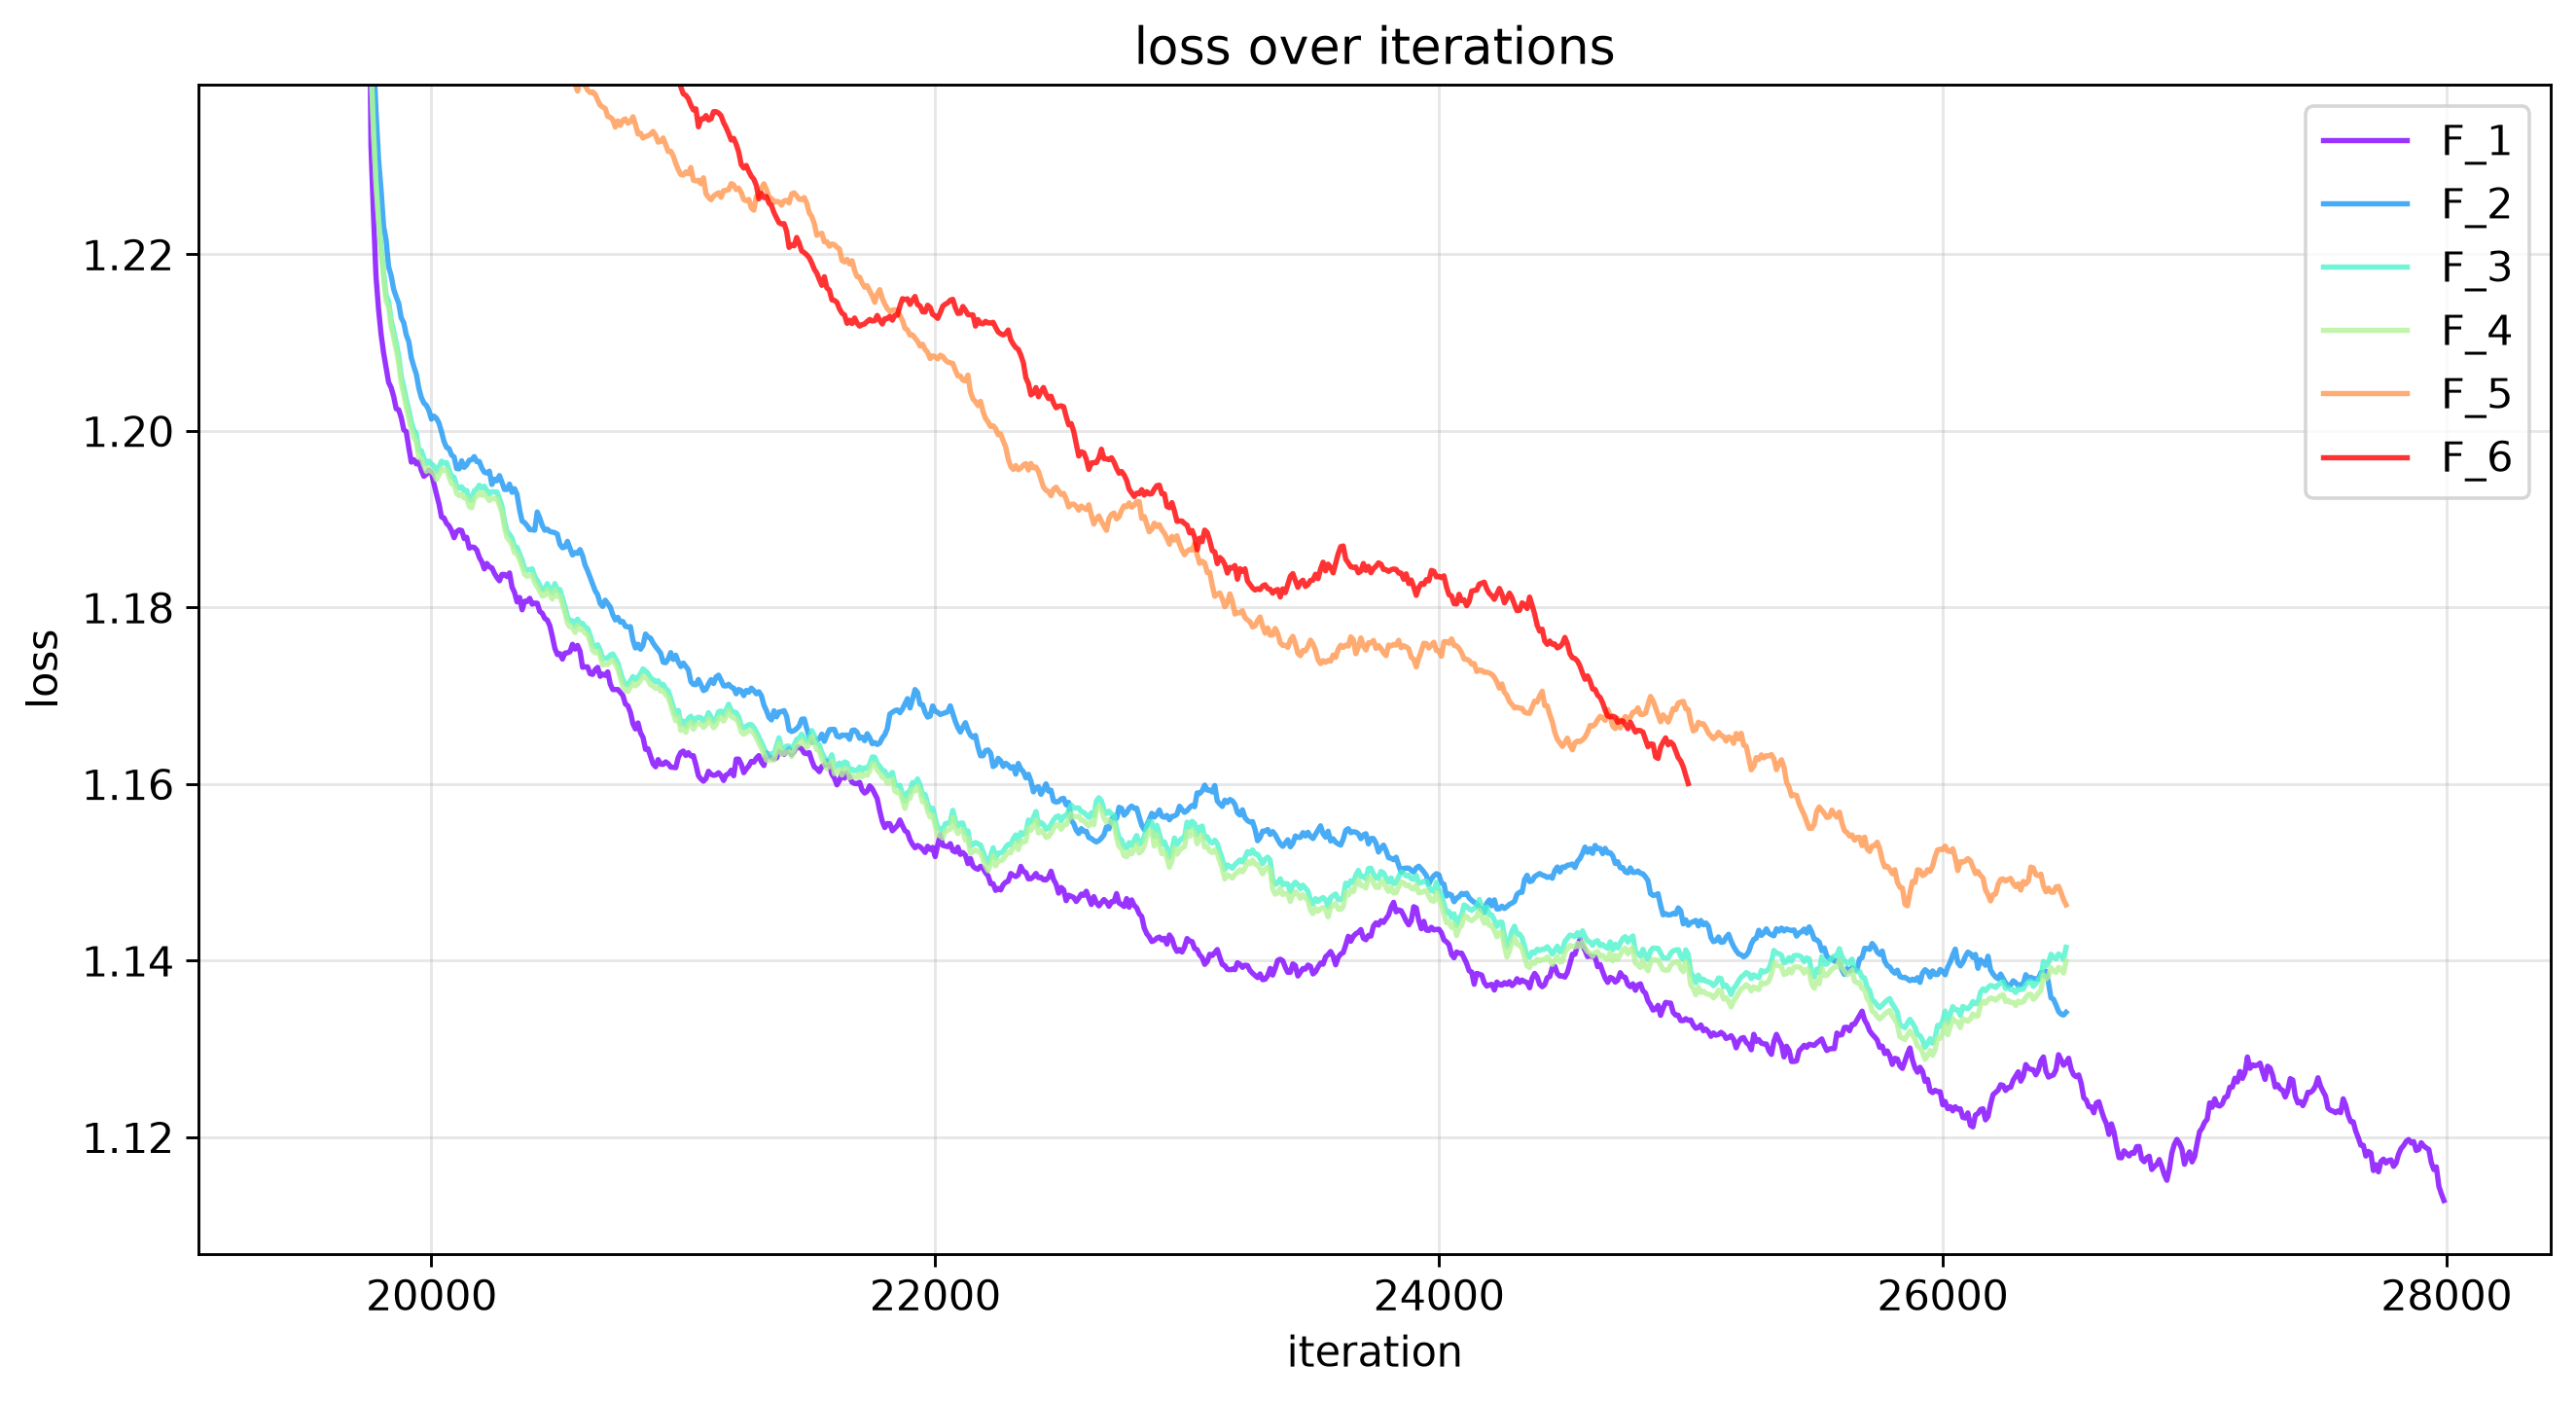

In [88]:
frange = list(range(1, 22))

draw_multiple(frange[:6], ylim_quantile=0.90)

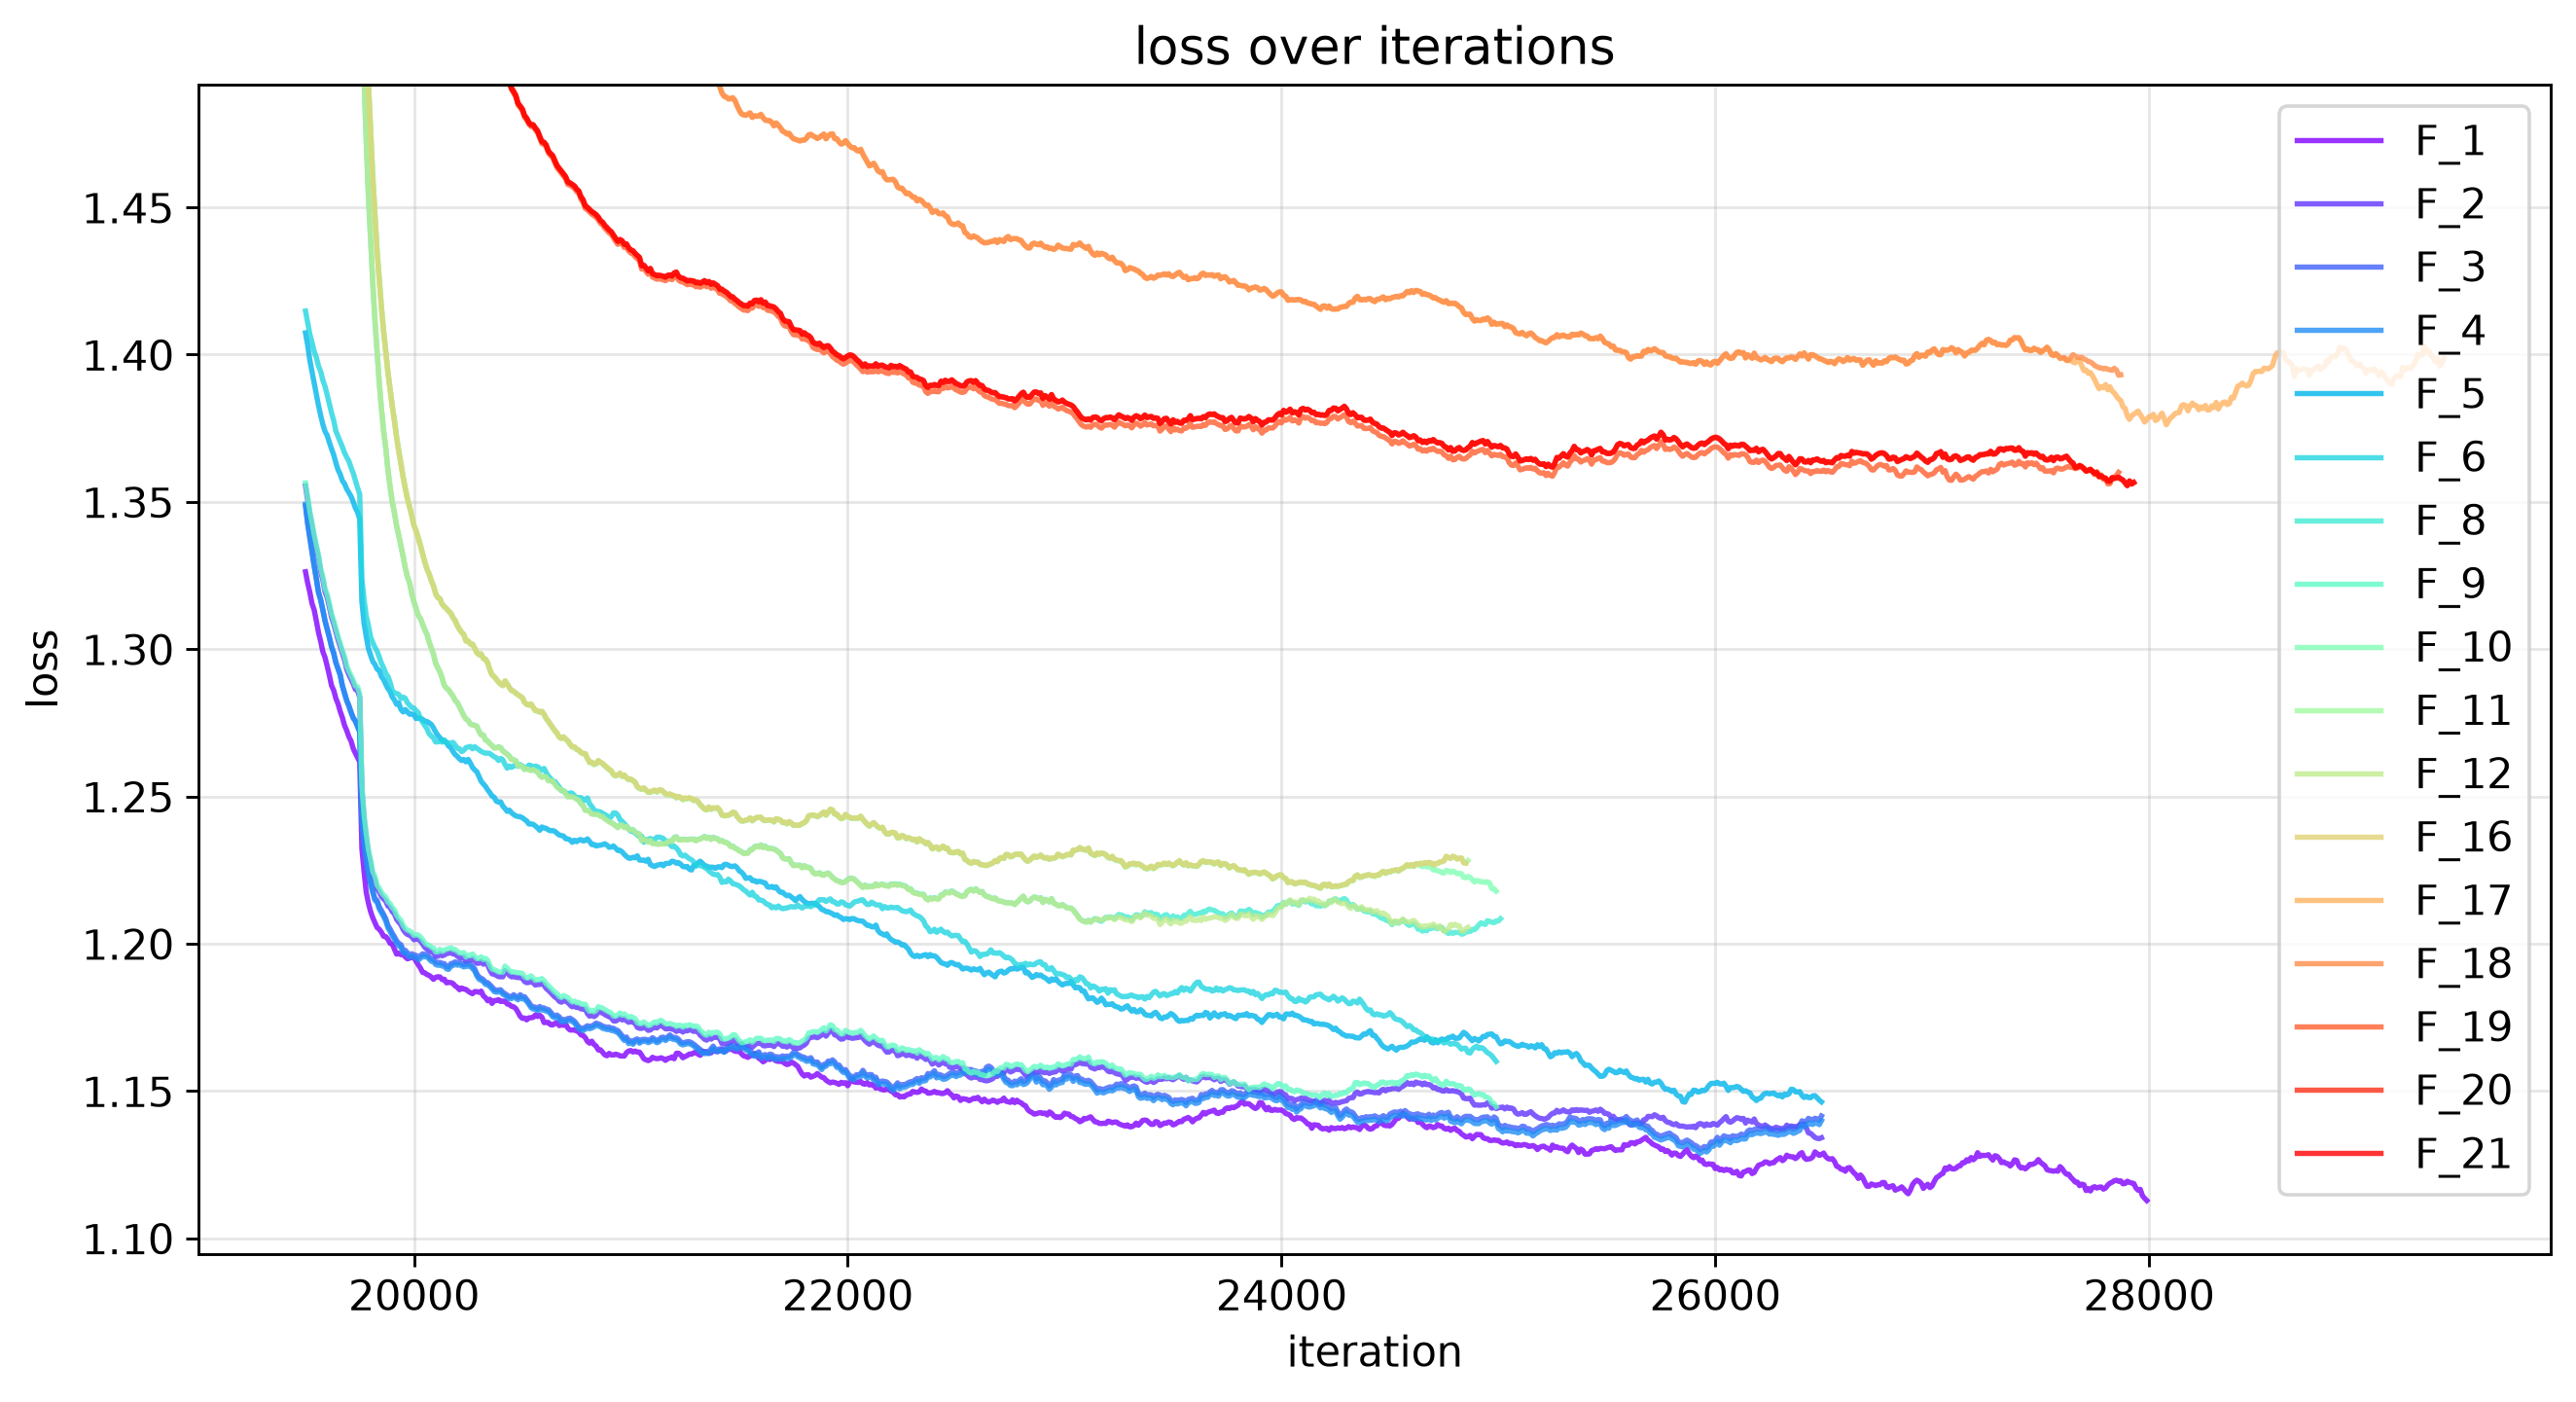

In [89]:
draw_multiple([1, 2, 3, 4, 5, 6, 8, 9, 10, 11, 12, 16, 17, 18, 19, 20, 21], ylim_quantile=0.92)

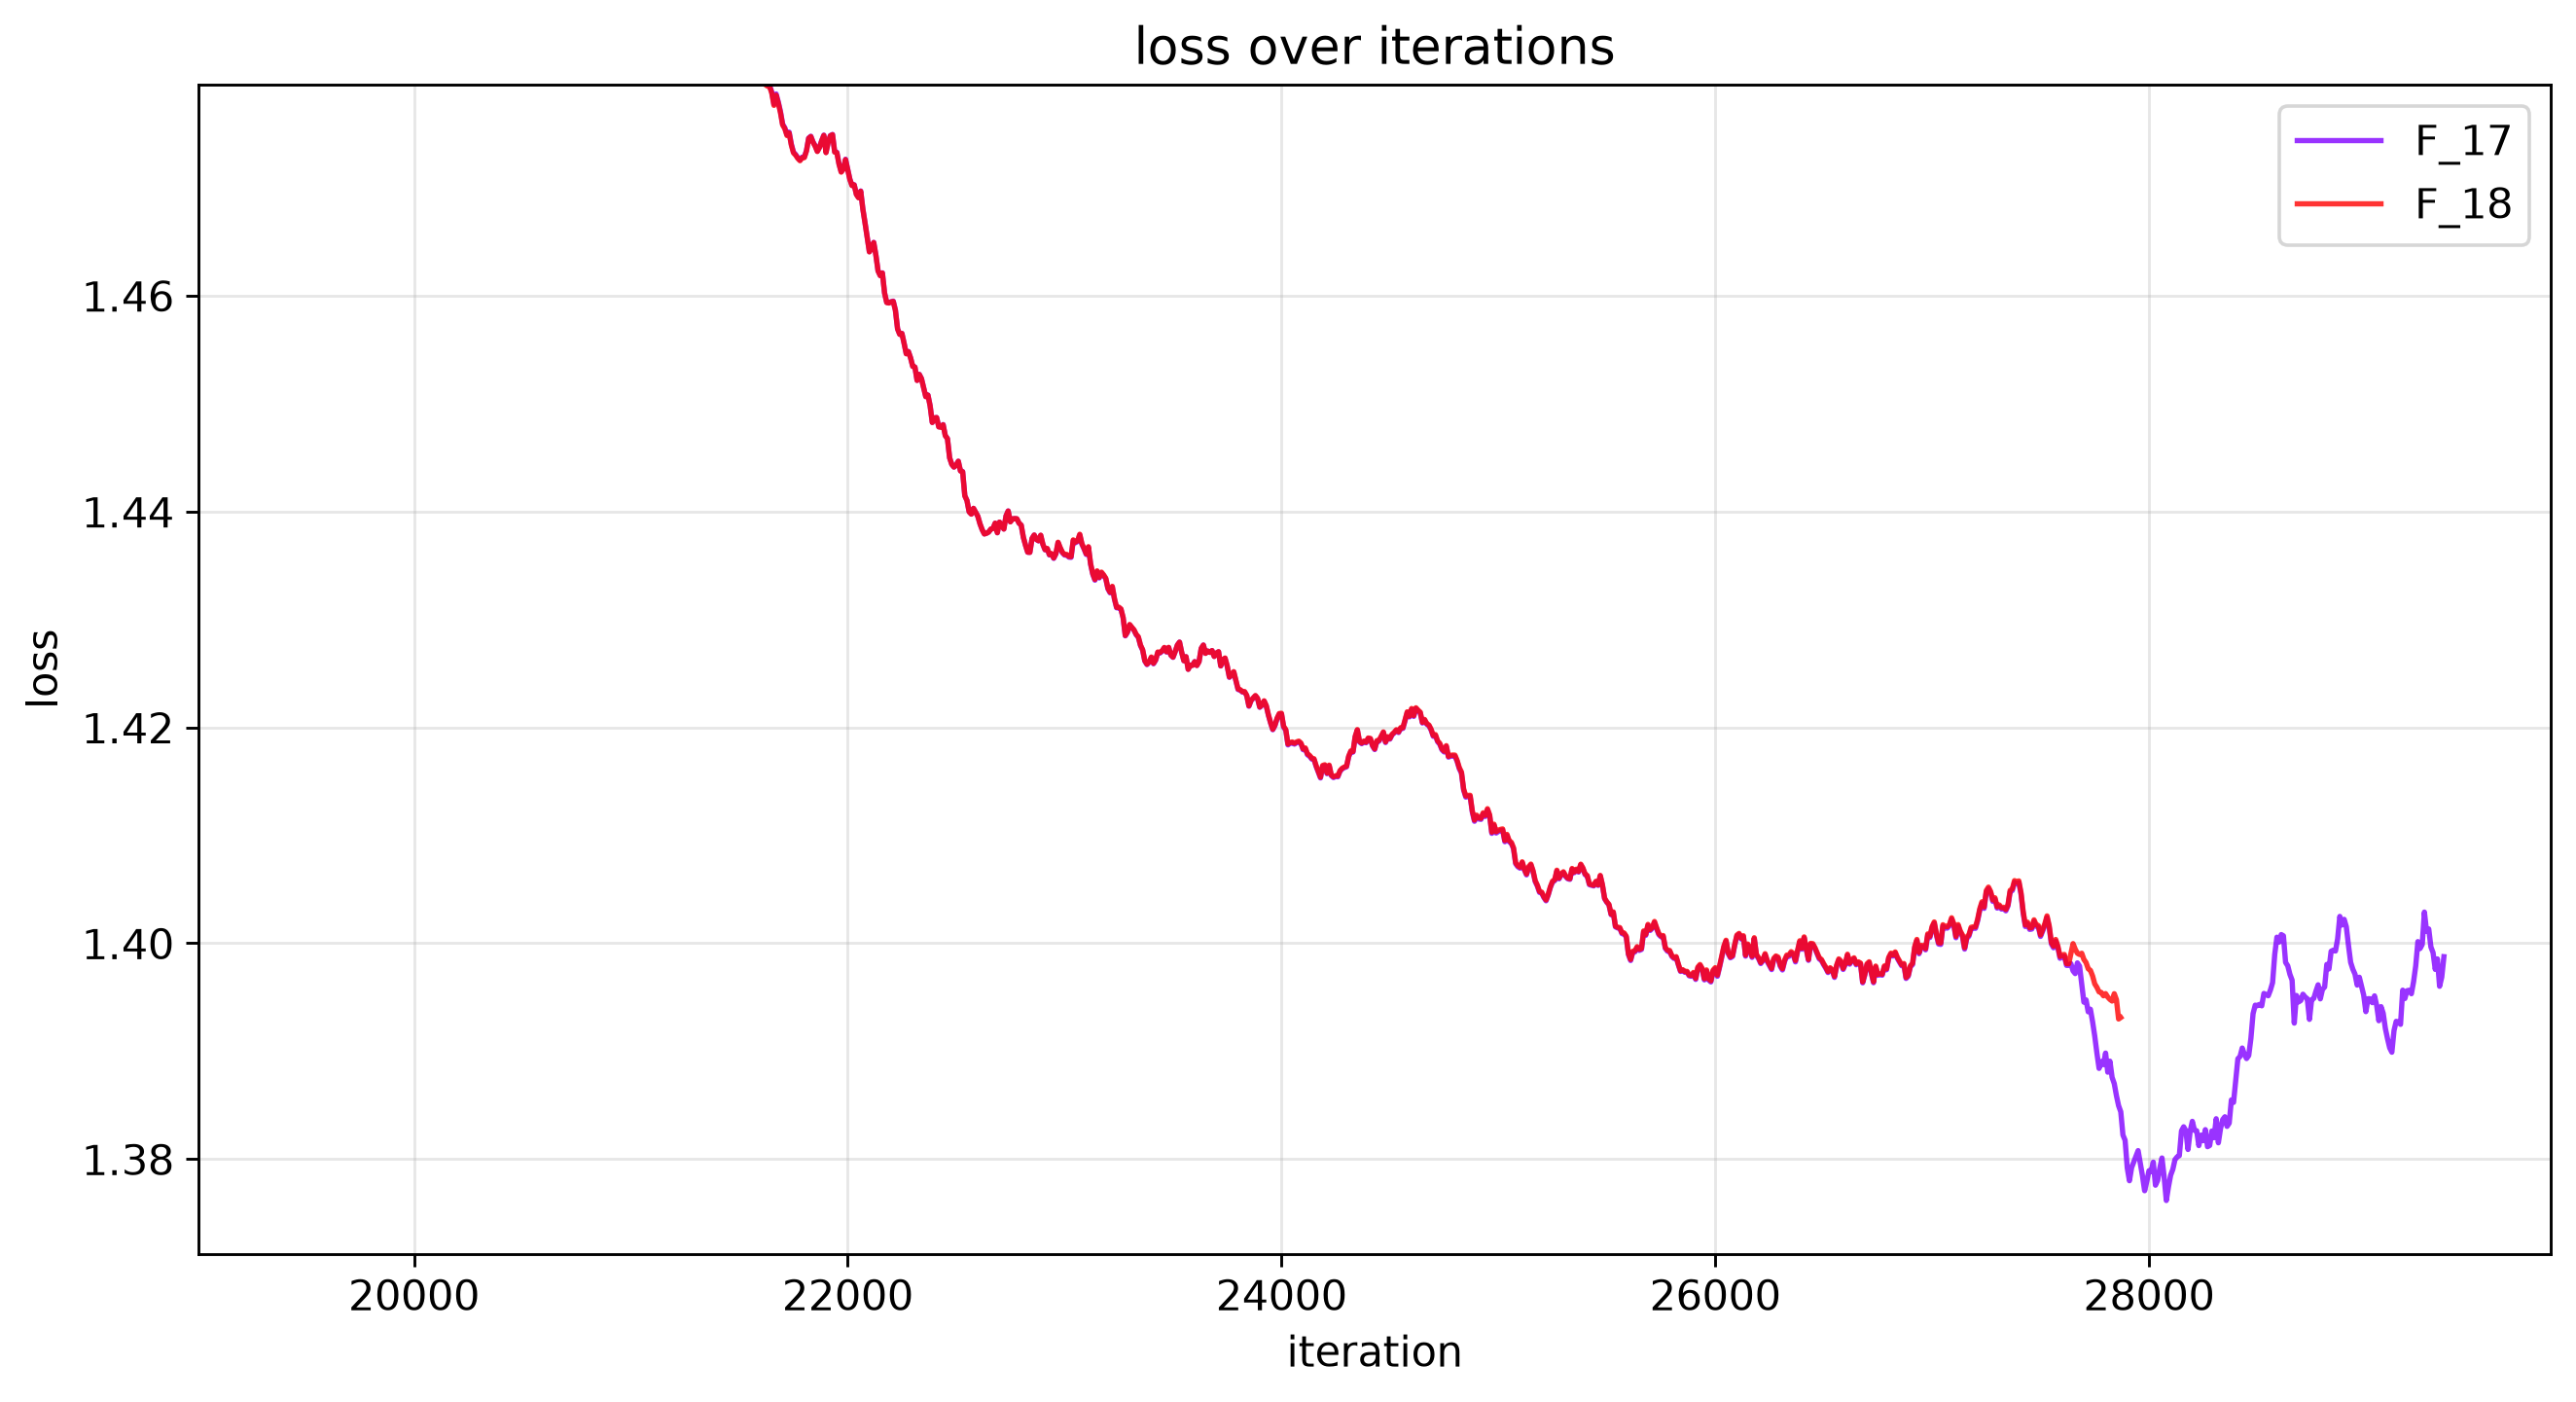

In [91]:
draw_multiple([17, 18], ylim_quantile=0.75)

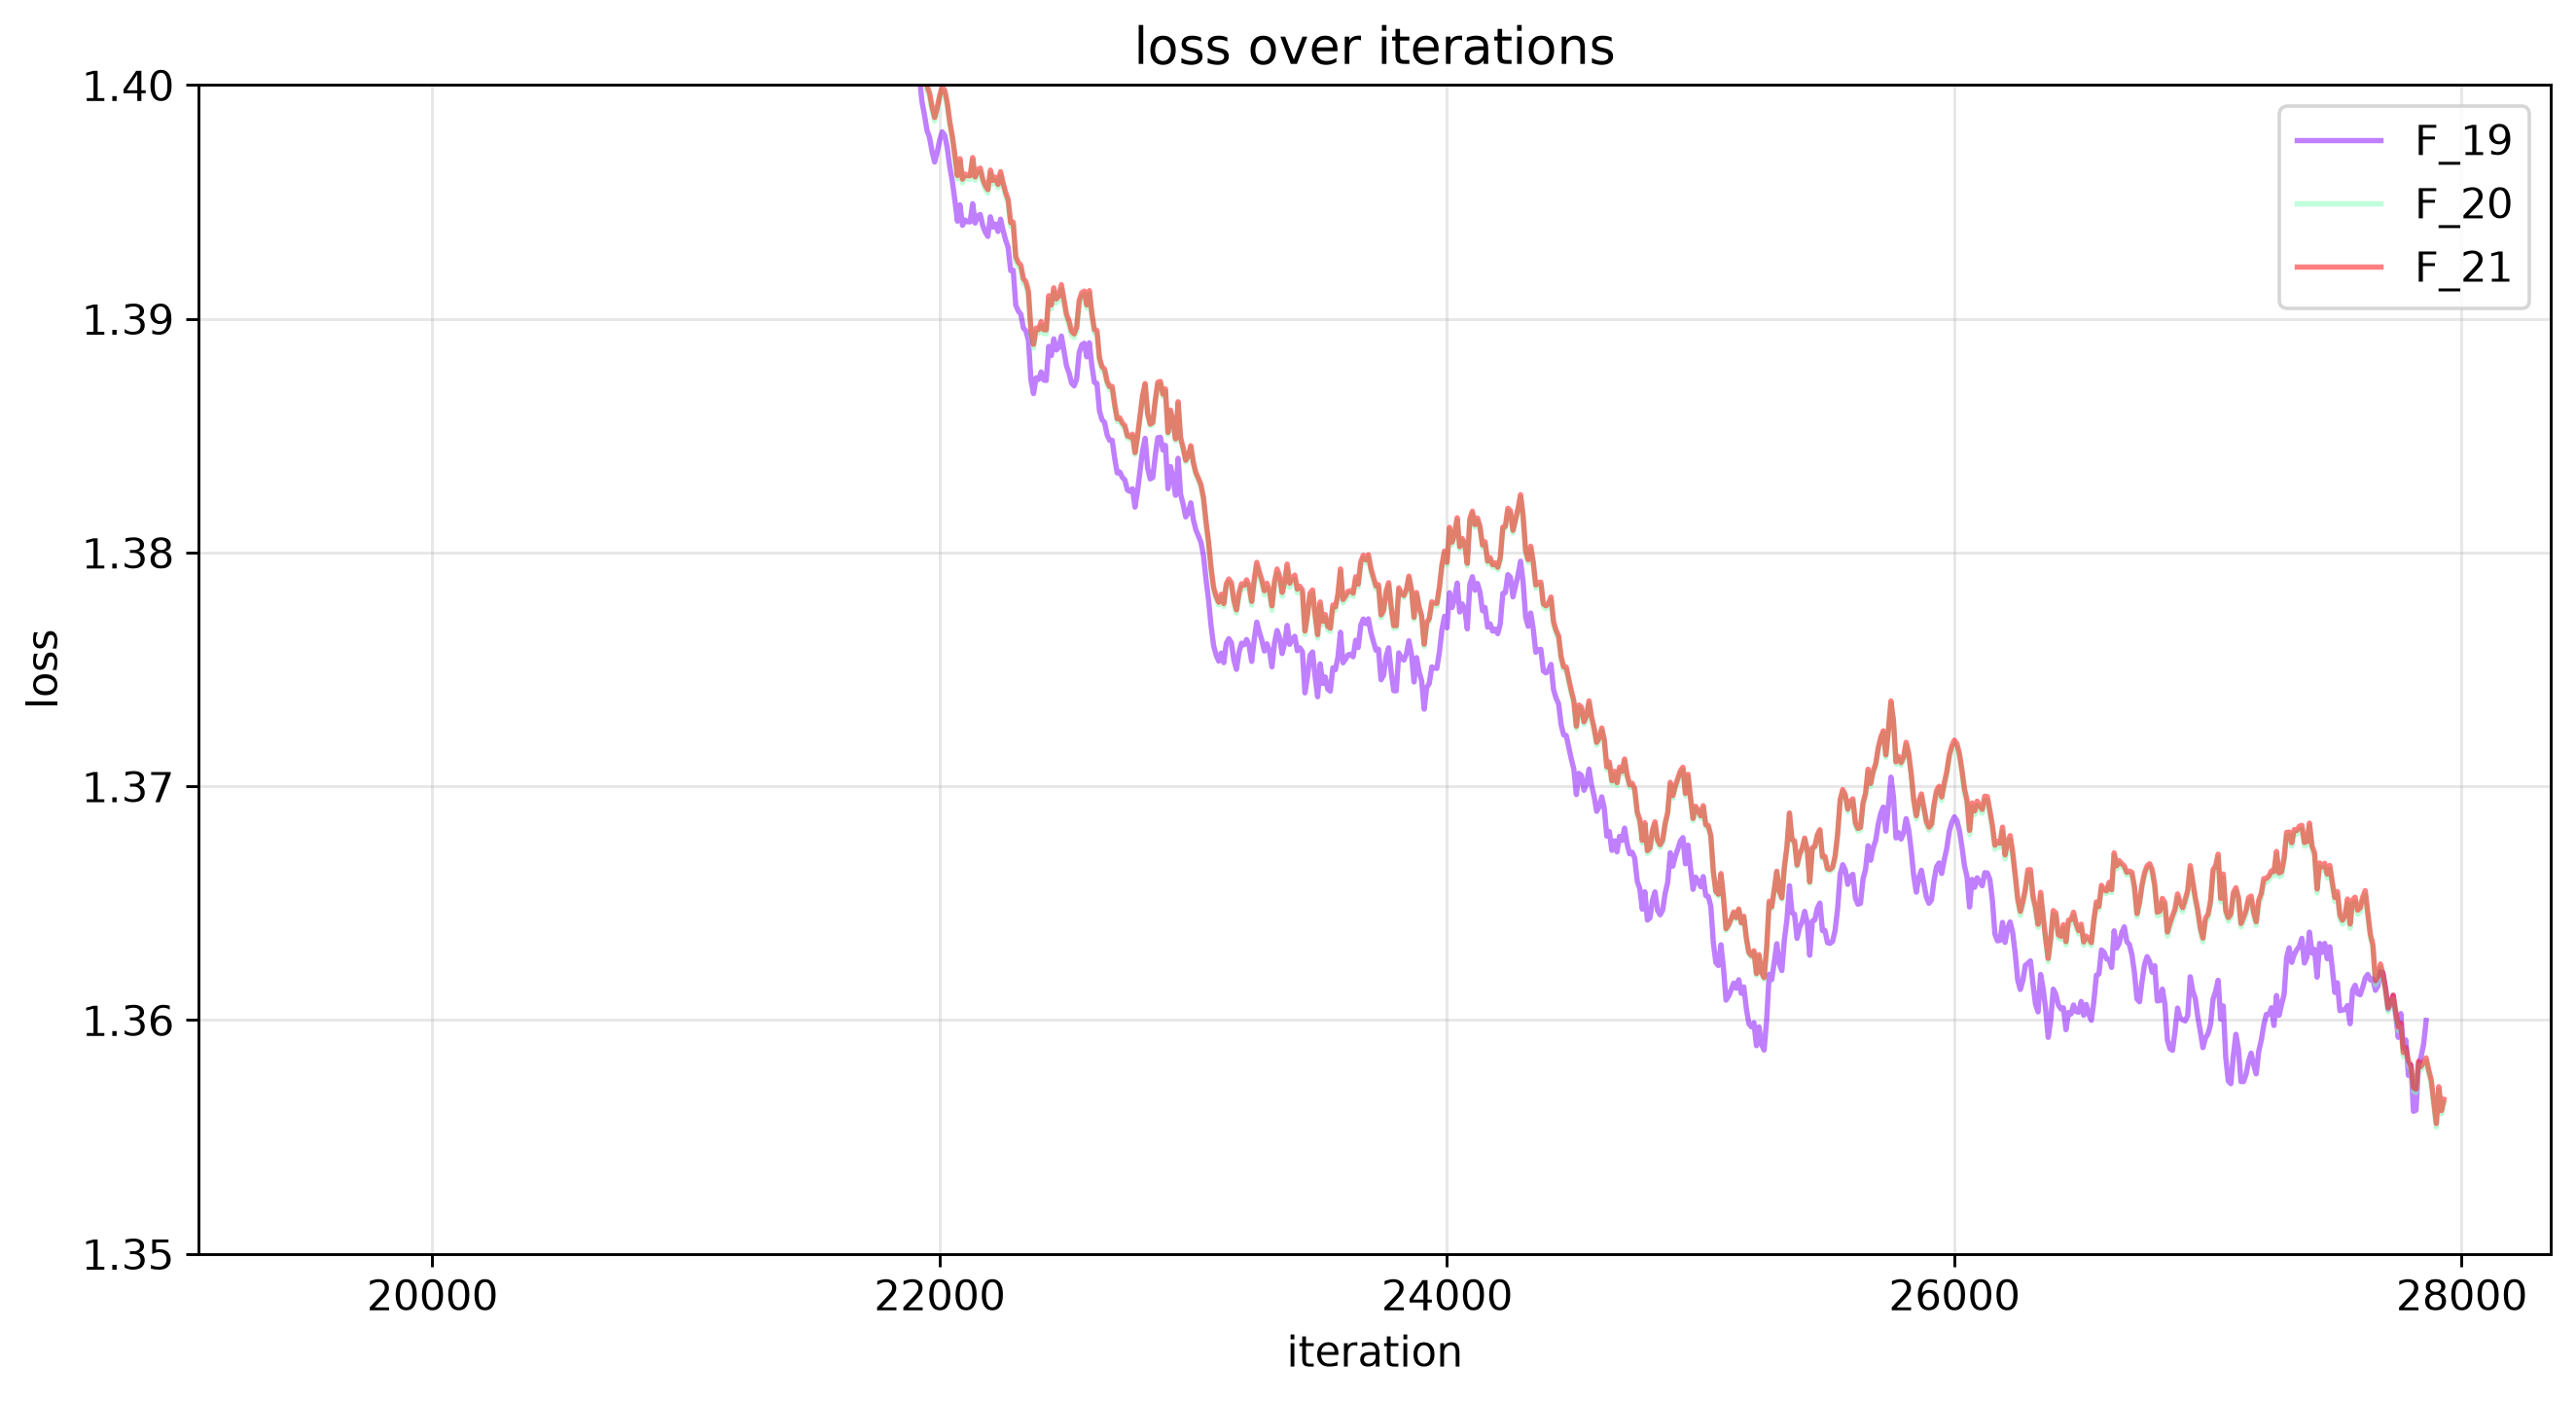

In [92]:
draw_multiple([19, 20, 21], alpha=0.5, ylim_quantile='manual2')